Pre and post aligned
{'minimum': -81.34020531664109, 'maximum': 21.104377808521313, 'mean': -11.22996862648854, 'std': 5.3951656288909104, 'valid_pixels': 15380333, 'nodata_pixels': 13057835}

{'minimum': -53.27936935424805, 'maximum': 28.159454345703125, 'mean': -13.525794982910156, 'std': 6.975342750549316, 'valid_pixels': 15378665, 'nodata_pixels': 13059503}


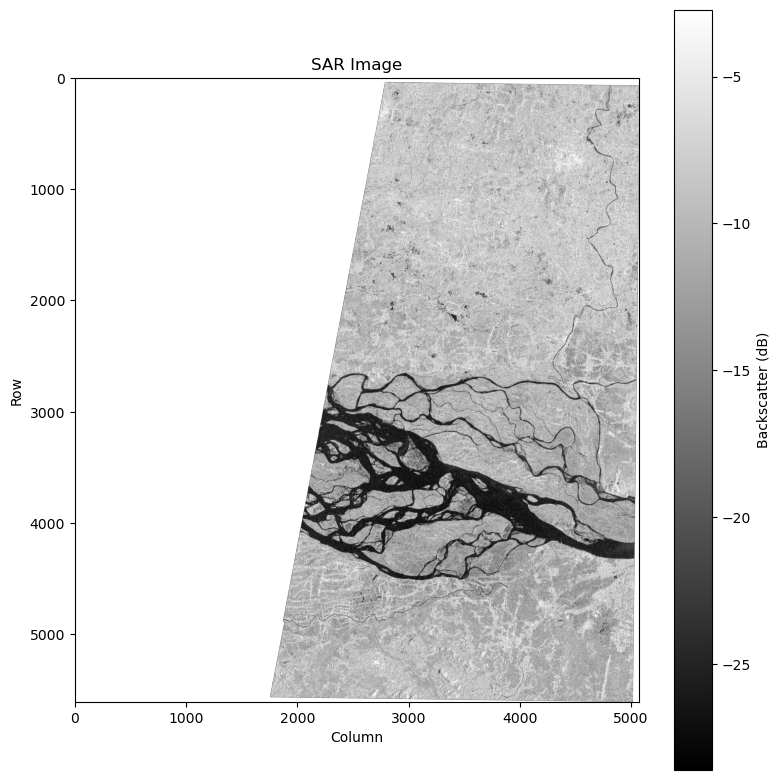

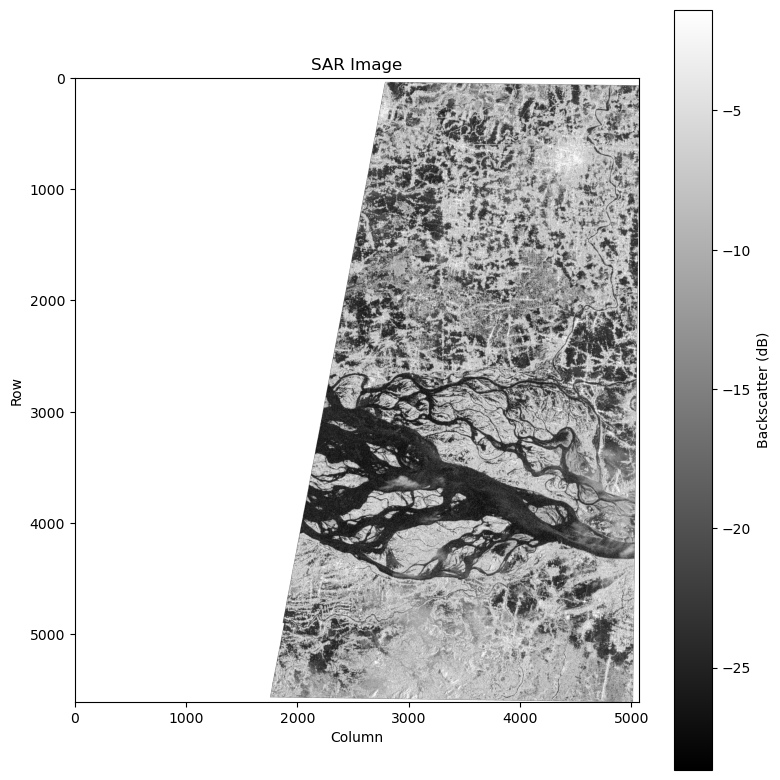

{'minimum': 7.344791441710182e-09, 'maximum': 128.95487976074222, 'mean': 0.12548591760321395, 'std': 0.24662683981382436, 'valid_pixels': 15380333, 'nodata_pixels': 13057835}

{'minimum': 4.699621058534831e-06, 'maximum': 654.5538330078125, 'mean': 0.12135935574769974, 'std': 0.6663994193077087, 'valid_pixels': 15378665, 'nodata_pixels': 13059503}



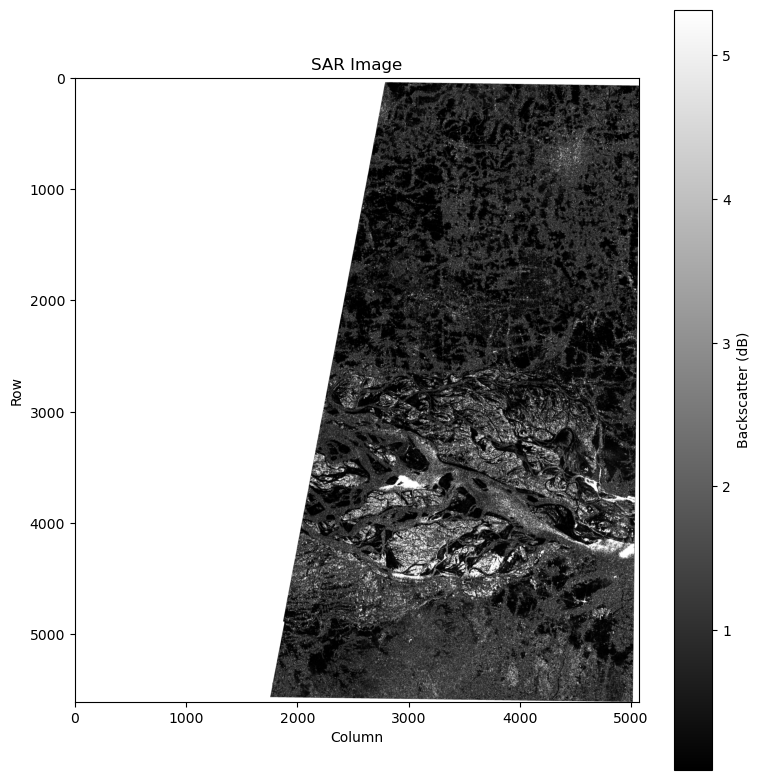


{'minimum': 0.0011617797385170673, 'maximum': 5649.941417001131, 'mean': 1.0750250813911488, 'std': 6.09996178039385, 'valid_pixels': 15367644, 'nodata_pixels': 13070524}



AttributeError: 'SARImage' object has no attribute 'show'

In [6]:
import os
import sys
module_path = os.path.abspath(os.path.expanduser("~/notebooks/geospatial/"))
# print(f"Module path is {module_path}")
# print(f"Sys path is {sys.path}")
if module_path not in sys.path:
    print("$$$$$$$$")
    sys.path.append(module_path)
    # print(f"Sys path is {sys.path}")
#sys.path.append(os.path.abspath(".."))
import numpy as np
from sar.sar_metadata import AcquisitionMetadata
from sar.sar_io import load_sar
from sar.sar_collection import SARCollection
from sar.sar_filters import lee_filter,_extract_window
from sar.sar_statistics import equivalent_number_of_looks
from sar.sar_statistics import coefficient_of_variation,local_mean
from sar.sar_radiometry import db_to_linear
from sar.sar_statistics import local_noise_variance
import matplotlib.pyplot as plt
from sar.sar_statistics import local_variance
from sar.sar_filters import _lee_weight,_estimate_noise_variance,frost_filter,_validate_filter_inputs,_pad_image
from sar.sar_geometry import _distance_matrix
from sar.sar_filters import _frost_weights
from sar.sar_statistics import _weighted_window_mean
from sar.sar_radiometry import linear_to_db
from sar.sar_geometry import _create_result
from sar.sar_change import *
from sar.sar_flood import *
from sar.sar_operations import copy_image,create_empty_like,align_to_reference,difference


#sys.path.append(os.path.abspath(".."))
# module_path = os.path.abspath(os.path.expanduser("~/notebooks"))
# print(f"Module path is {module_path}")
# print(f"Sys path is {sys.path}")
# if module_path not in sys.path:
#     print("$$$$$$$$")
#     sys.path.append(module_path)

FILTER = "Frost"

WINDOW_SIZE = 5

THRESHOLD = 0.35

POLARIZATION = "VV"

pre = load_sar("/home/ubuntu/notebooks/geospatial/sample_image_preflood1.tif")

post = load_sar("/home/ubuntu/notebooks/geospatial/sample_image_postflood1.tif")


collection = SARCollection()


pre_metadata = AcquisitionMetadata(
    platform="Sentinel-1A",
    sensor="SAR",
    acquisition_date="2022-05-01",
    polarization="VV",
    orbit_direction="DESCENDING",
    relative_orbit=77,
    beam_mode="IW",
    frequency_band="C",
)

pre = load_sar(
    "/home/ubuntu/notebooks/geospatial/sample_image_preflood1.tif",
    acquisition=pre_metadata,
)

post_metadata = AcquisitionMetadata(
    platform="Sentinel-1A",
    sensor="SAR",
    
    acquisition_date="2022-07-24",
    polarization="VV",
    orbit_direction="DESCENDING",
    relative_orbit=77,
    beam_mode="IW",
    frequency_band="C",
)

post = load_sar(
    "/home/ubuntu/notebooks/geospatial/sample_image_postflood1.tif",
    acquisition=post_metadata,
)

empty = create_empty_like(pre)

aligned_post = align_to_reference(
    pre,
    post
)
print("Pre and post aligned")
print(pre.statistics())
print()
print(aligned_post.statistics())

pre.plot()

post.plot()
      
pre_linear = db_to_linear(pre)
post_linear = db_to_linear(aligned_post)

print(pre_linear.statistics())
print()
print(post_linear.statistics())

if FILTER.lower() == "lee":

    pre_filtered = lee_filter(pre_linear)

    post_filtered = lee_filter(post_linear)

elif FILTER.lower() == "frost":

    pre_filtered = frost_filter(
        pre_linear,
        window_size=WINDOW_SIZE,
    )

    post_filtered = frost_filter(
        post_linear,
        window_size=WINDOW_SIZE,
    )

else:

    raise ValueError(
        "Unknown filter."
    )


ratio = ratio_change(
    pre_filtered,
    post_filtered,
)

print()
ratio.plot()
print()
print(ratio.statistics())
print()

flood = threshold_flood(
    ratio,
    threshold=THRESHOLD,
)

flood.plot()

flood_pixels = np.sum(
    flood.data == 1
)

valid_pixels = np.sum(
    flood.mask
)

percent = (
    flood_pixels
    /
    valid_pixels
    *
    100
)

print(f"Flood pixels : {flood_pixels:,}")

print(f"Flood %      : {percent:.2f}")

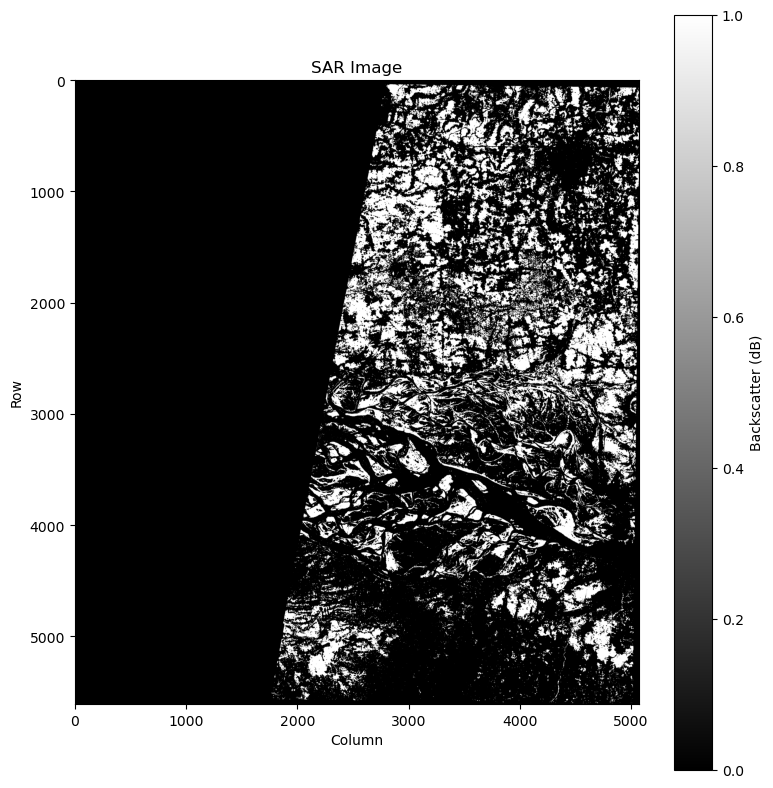

Flood pixels : 4,280,892
Flood %      : 27.86
428.0892


In [8]:
flood.plot()

flood_pixels = np.sum(
    flood.data == 1
)

valid_pixels = np.sum(
    flood.mask
)

percent = (
    flood_pixels
    /
    valid_pixels
    *
    100
)

print(f"Flood pixels : {flood_pixels:,}")

print(f"Flood %      : {percent:.2f}")

pixel_area = 100

area_m2 = (
    flood_pixels
    *
    pixel_area
)

area_km2 = area_m2 / 1_000_000

print(area_km2)

In [ ]:
module_path = os.path.abspath(os.path.expanduser("~/notebooks"))

In [ ]:
print(os.path.abspath(".."))
print(sys.path)
print(module_path)